# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera ? MLflow ? Optuna ? Evidently ? SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts ? at a cost of ?8?15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   ? 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` ? 1,499 readings from the current stable production batch
- `data/stress.csv`  ? 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

## **1. Data Loading, Schema Validation & EDA** <font color=red>[15 marks]</font>

### **1.1** <font color=red>[3 marks]</font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the three datasets
train   = pd.read_csv('data/train.csv')
current = pd.read_csv('data/current.csv')
stress  = pd.read_csv('data/stress.csv')

# TODO: Print shapes
print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# TODO: Display first 5 rows of train
train.head()


train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [9]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# define schema matching the domain constraints from the brief
schema = DataFrameSchema({
    'Type':                 Column(str,     Check.isin(['L', 'M', 'H'])),
    'Air temperature':      Column(float,   Check.in_range(295.0, 305.0)),
    'Process temperature':  Column(float,   Check.in_range(305.0, 315.0)),
    'Rotational speed':     Column('int64', Check.in_range(1000, 2900)),
    'Torque':               Column(float,   Check.in_range(3.0, 80.0)),
    'Tool wear':            Column('int64', Check.in_range(0, 253)),
    'Failure_Type':         Column('int64', Check.isin([0, 1, 2, 3, 4])),
})

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# train and current should pass cleanly
try:
    schema.validate(train)
    print("train  : schema OK")
except pa.errors.SchemaErrors as e:
    print(f"train  : {len(e.failure_cases)} violation(s) found")

try:
    schema.validate(current)
    print("current: schema OK")
except pa.errors.SchemaErrors as e:
    print(f"current: {len(e.failure_cases)} violation(s) found")

# stress uses lazy=True — collects all violations before raising
# note: stress is designed to be *valid but drifted*, so it may pass here
try:
    schema.validate(stress, lazy=True)
    print("stress : schema OK (values are valid)")
except pa.errors.SchemaErrors as e:
    summary = e.failure_cases[['column', 'failure_case']].value_counts()
    print(f"stress : {len(e.failure_cases)} violation(s) found")
    print(summary.to_string())


train  : schema OK
current: schema OK
stress : schema OK (values are valid)


### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


Class distribution (train):
  0  No Failure     :  6762  (96.7%)
  1  TWF            :    30  (0.4%)
  2  HDF            :    76  (1.1%)
  3  PWF            :    56  (0.8%)
  4  OSF            :    69  (1.0%)


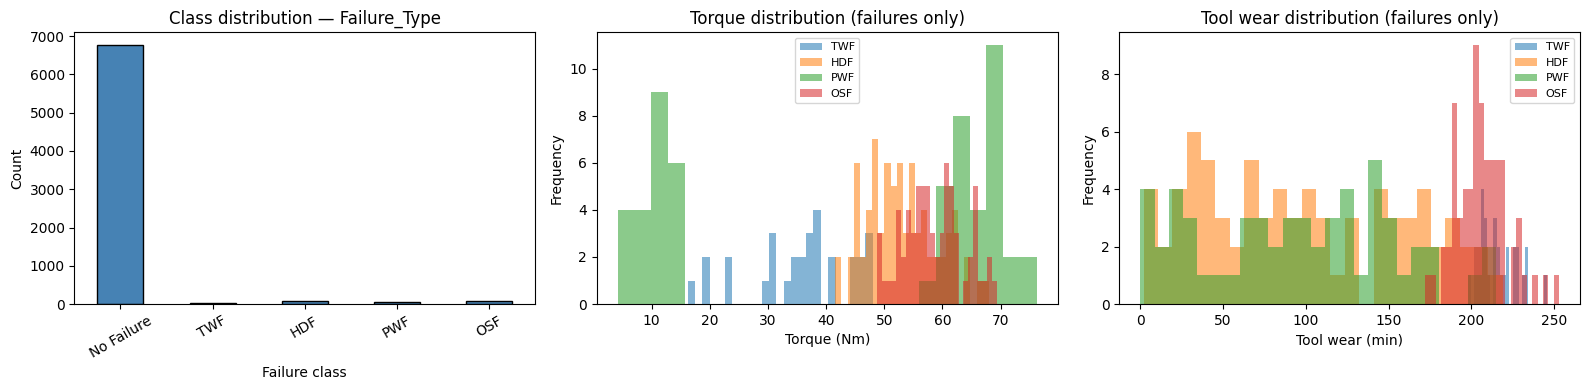

Saved eda_distributions.png

Machine type distribution (train):
Type
L    4213
M    2074
H     706


In [11]:
# --- class distribution ---
class_counts = train['Failure_Type'].value_counts().sort_index()
print("Class distribution (train):")
for k, v in class_counts.items():
    pct = v / len(train) * 100
    print(f"  {k}  {CLASS_NAMES[k]:<15}: {v:>5}  ({pct:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# bar chart of class counts
class_counts.rename(CLASS_NAMES).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Class distribution — Failure_Type')
axes[0].set_xlabel('Failure class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# isolate actual failures only
failures = train[train['Failure_Type'] != 0].copy()

# torque by failure class
for ftype, grp in failures.groupby('Failure_Type'):
    grp['Torque'].plot(kind='hist', bins=25, alpha=0.55,
                       label=CLASS_NAMES[ftype], ax=axes[1])
axes[1].set_title('Torque distribution (failures only)')
axes[1].set_xlabel('Torque (Nm)')
axes[1].legend(fontsize=8)

# tool wear by failure class
for ftype, grp in failures.groupby('Failure_Type'):
    grp['Tool wear'].plot(kind='hist', bins=25, alpha=0.55,
                          label=CLASS_NAMES[ftype], ax=axes[2])
axes[2].set_title('Tool wear distribution (failures only)')
axes[2].set_xlabel('Tool wear (min)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150)
plt.show()
print("Saved eda_distributions.png")

# Type (L / M / H) distribution
print("\nMachine type distribution (train):")
print(train['Type'].value_counts().to_string())



### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [12]:
def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    # mechanical power: P = Torque * angular_velocity  (W)
    df['Power_W']   = df['Torque'] * (df['Rotational speed'] * 2 * np.pi / 60)
    # TODO: Compute Temp_diff
    # temperature differential between process and air (K)
    df['Temp_diff'] = df['Process temperature'] - df['Air temperature']
    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# grouped means help us see whether these features separate failure types
print("Mean Power_W and Temp_diff by Failure_Type:")
grouped = (
    train.groupby('Failure_Type')[['Power_W', 'Temp_diff']]
    .mean()
    .rename(index=CLASS_NAMES)
    .round(2)
)
print(grouped.to_string())


Mean Power_W and Temp_diff by Failure_Type:
              Power_W  Temp_diff
Failure_Type                    
No Failure    6248.24      10.01
TWF           5763.09       9.97
HDF           7403.55       8.23
PWF           6664.38       9.82
OSF           8216.07      10.07


## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# TODO: Encode Type column
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
# TODO: Define X and y
X = train[FEATURES]
y = train['Failure_Type']

# TODO: Train-val split
# stratified split so rare classes appear in both halves
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
sm = SMOTE(k_neighbors=3, random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

# TODO: Print post-SMOTE class distribution
print("Post-SMOTE class distribution (training set):")
for k, v in pd.Series(y_res).value_counts().sort_index().items():
    print(f"  {k}  {CLASS_NAMES[k]:<15}: {v}")
print(f"\nPre-SMOTE training size : {len(X_train)}")
print(f"Post-SMOTE training size: {len(X_res)}")


Post-SMOTE class distribution (training set):
  0  No Failure     : 5409
  1  TWF            : 5409
  2  HDF            : 5409
  3  PWF            : 5409
  4  OSF            : 5409

Pre-SMOTE training size : 5594
Post-SMOTE training size: 27045


**Why SMOTE is applied only on the training split:**

SMOTE generates synthetic minority-class samples by interpolating between real neighbours in feature space. If we applied it before splitting, some synthetic points would be derived from validation-set neighbours, meaning information about those held-out rows would bleed into the training data — a form of data leakage. By splitting first and then applying SMOTE only to `X_train`, the validation set (`X_val`, `y_val`) contains exclusively real, unseen examples. This ensures that our `macro_f1` scores on the validation set reflect genuine generalisation ability rather than inflated performance caused by synthetic-data contamination.


### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [19]:
# 2.2 Train and log 4 models with MLflow
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = {}

# Define all models to run
models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42,
                                           class_weight='balanced'),
    'XGBoost':      XGBClassifier(n_estimators=100, random_state=42,
                                   eval_metric='mlogloss', verbosity=0),
    'LightGBM':     LGBMClassifier(n_estimators=100, random_state=42,
                                    class_weight='balanced', verbose=-1),
}

# For each model:
#   - Start an MLflow run
#   - Fit on X_res, y_res
#   - Predict on X_val
#   - Compute and log macro_f1, weighted_f1, accuracy, per-class F1
#   - Log the model artefact (input_example removed due to pandas/MLflow incompatibility)
for name, model in models_to_run.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_res, y_res)
        preds = model.predict(X_val)

        # Compute metrics
        macro_f1    = f1_score(y_val, preds, average='macro',    zero_division=0)
        weighted_f1 = f1_score(y_val, preds, average='weighted', zero_division=0)
        acc         = accuracy_score(y_val, preds)
        per_class   = f1_score(y_val, preds, average=None,
                               labels=CLASS_LIST, zero_division=0)

        # Log parameters and metrics to MLflow
        mlflow.log_param('model', name)
        mlflow.log_metric('macro_f1',    macro_f1)
        mlflow.log_metric('weighted_f1', weighted_f1)
        mlflow.log_metric('accuracy',    acc)
        for cls_id, f1_val in zip(CLASS_LIST, per_class):
            mlflow.log_metric(f'f1_class_{cls_id}', f1_val)
        # Log the model artefact (input_example removed due to incompatibility between MLflow and pandas >=2.2.0)
        mlflow.sklearn.log_model(model, artifact_path='model')

        # Store results for comparison table
        results[name] = {
            'macro_f1':    macro_f1,
            'weighted_f1': weighted_f1,
            'accuracy':    acc,
            **{f'f1_{CLASS_NAMES[c]}': per_class[i]
               for i, c in enumerate(CLASS_LIST)}
        }

    print(f"{name:<22}  macro_f1={macro_f1:.4f}  acc={acc:.4f}")

# Print comparison table sorted by macro F1 (the metric that matters here)
results_df = pd.DataFrame(results).T.sort_values('macro_f1', ascending=False)
print("\nFull comparison table:")
print(results_df.round(4).to_string())

# Identify best model by macro F1
best_model_name = results_df.index[0]
print(f"\nBest model: {best_model_name}"
      f"  (macro_f1 = {results_df.loc[best_model_name, 'macro_f1']:.4f})")


2026/05/04 14:19:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 14:19:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LogisticRegression      macro_f1=0.5312  acc=0.9042


2026/05/04 14:19:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 14:19:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest            macro_f1=0.7355  acc=0.9850


2026/05/04 14:19:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 14:19:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost                 macro_f1=0.7481  acc=0.9843


2026/05/04 14:20:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 14:20:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM                macro_f1=0.7296  acc=0.9843

Full comparison table:
                    macro_f1  weighted_f1  accuracy  f1_No Failure  f1_TWF  f1_HDF  f1_PWF  f1_OSF
XGBoost               0.7481       0.9851    0.9843         0.9922  0.1333  0.9655  0.8800  0.7692
RandomForest          0.7355       0.9855    0.9850         0.9926  0.0000  0.9286  0.9565  0.8000
LightGBM              0.7296       0.9851    0.9843         0.9922  0.0000  0.9655  0.8333  0.8571
LogisticRegression    0.5312       0.9328    0.9042         0.9483  0.1449  0.4545  0.4583  0.6500

Best model: XGBoost  (macro_f1 = 0.7481)


### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [21]:
import optuna
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

# keep a reference to the baseline so we can measure the improvement
baseline_xgb_f1 = results['XGBoost']['macro_f1']

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':            trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    clf = XGBClassifier(**params)
    clf.fit(X_res, y_res)
    preds = clf.predict(X_val)
    return f1_score(y_val, preds, average='macro', zero_division=0)

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest trial  : {study.best_trial.number}")
print(f"Best macro_f1: {study.best_value:.4f}")

# train the final model using the best params found by Optuna
best_params = {
    **study.best_params,
    'random_state': 42,
    'eval_metric':  'mlogloss',
    'verbosity':    0,
}
tuned_model = XGBClassifier(**best_params)
tuned_model.fit(X_res, y_res)

tuned_preds = tuned_model.predict(X_val)
tuned_macro = f1_score(y_val, tuned_preds, average='macro', zero_division=0)

print(f"\nBaseline XGBoost macro_f1 : {baseline_xgb_f1:.4f}")
print(f"Tuned    XGBoost macro_f1 : {tuned_macro:.4f}")
print(f"Improvement               : +{tuned_macro - baseline_xgb_f1:.4f}")

# log to MLflow and register in Model Registry
with mlflow.start_run(run_name='XGBoost_Optuna_best'):
    mlflow.log_params(study.best_params)
    mlflow.log_metric('macro_f1', tuned_macro)
    # Log the model artefact (input_example removed due to incompatibility between MLflow and pandas >=2.2.0)
    mlflow.sklearn.log_model(
        tuned_model,
        artifact_path='model',
        registered_model_name='PredMaint_XGBoost',
    )

# promote the latest version to the production alias
client  = mlflow.tracking.MlflowClient()
latest  = client.get_registered_model('PredMaint_XGBoost').latest_versions[-1]
client.set_registered_model_alias('PredMaint_XGBoost', 'production', latest.version)
print(f"\nRegistered 'PredMaint_XGBoost' v{latest.version} → alias 'production'")

# save locally for SHAP and inference
joblib.dump(tuned_model, 'best_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("Saved best_model.pkl  and  label_encoder.pkl")


Best trial: 15. Best value: 0.757304: 100%|██████████| 30/30 [00:58<00:00,  1.95s/it]



Best trial  : 15
Best macro_f1: 0.7573


2026/05/04 14:27:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 14:27:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Baseline XGBoost macro_f1 : 0.7481
Tuned    XGBoost macro_f1 : 0.7573
Improvement               : +0.0092

Registered 'PredMaint_XGBoost' v1 → alias 'production'
Saved best_model.pkl  and  label_encoder.pkl


Successfully registered model 'PredMaint_XGBoost'.
Created version '1' of model 'PredMaint_XGBoost'.


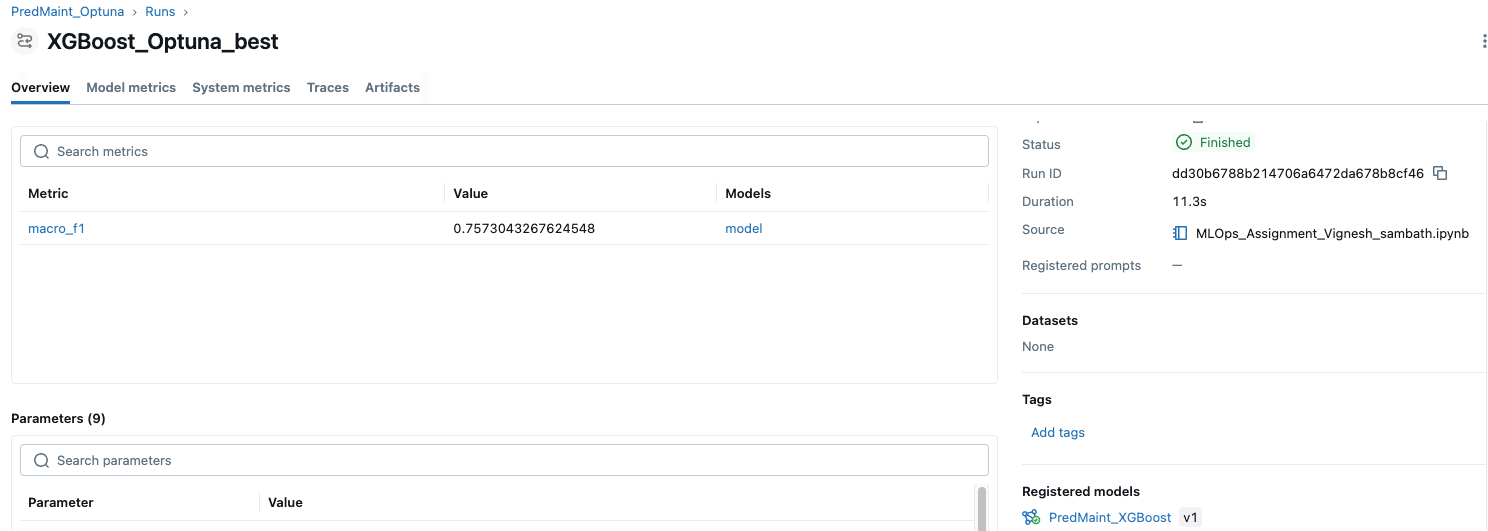

## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [23]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
# TODO: Run Evidently on current batch, save drift_current.html, print summary

# run Evidently on the current batch
report_current = Report(metrics=[DataDriftPreset()])
report_current.run(
    reference_data=train[FEAT_COLS],
    current_data=current[FEAT_COLS]
)
report_current.save_html('drift_current.html')

# pull summary
res = report_current.as_dict()['metrics'][0]['result']
drift_flag = res['dataset_drift']
n_drifted  = res['number_of_drifted_columns']

print(f"\nCurrent batch drift report:")
print(f"  Dataset drift detected : {drift_flag}")
print(f"  Features drifted       : {n_drifted} / {len(FEAT_COLS)}")
print("Saved drift_current.html")



Current batch drift report:
  Dataset drift detected : False
  Features drifted       : 0 / 5
Saved drift_current.html


### **3.2** <font color=red>[4 marks]</font> Evidently ? stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [26]:
# Run Evidently on stress batch with per-column metrics, save drift_stress.html, and print per-column drift table
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric

# Build one report that covers overall drift + a dedicated metric per feature
col_metrics = [DatasetDriftMetric()] + [
    ColumnDriftMetric(column_name=c) for c in FEAT_COLS
]

# Run Evidently on the stress batch (train vs stress)
report_stress = Report(metrics=col_metrics)
report_stress.run(
    reference_data=train[FEAT_COLS],
    current_data=stress[FEAT_COLS]
)

# Save the drift report as drift_stress.html
report_stress.save_html('drift_stress.html')
print("Saved drift_stress.html")

# Parse per-feature results into a readable table
raw_metrics = report_stress.as_dict()['metrics']

rows = []
for entry in raw_metrics[1:]:   # index 0 is the dataset-level summary
    r      = entry['result']
    col    = r['column_name']
    rows.append({
        'feature':      col,
        'drift':        r['drift_detected'],
        'wasserstein':  round(r['drift_score'], 4),
        'ref_mean':     round(train[col].mean(), 2),
        'stress_mean':  round(stress[col].mean(), 2),
        'delta':        round(stress[col].mean() - train[col].mean(), 2),
    })

# Print per-column drift table
drift_table = pd.DataFrame(rows).set_index('feature')
print("\nPer-feature drift — stress batch vs training baseline:")
print(drift_table.to_string())

# Also print overall dataset drift verdict
ds_res = raw_metrics[0]['result']
print(f"\nOverall dataset drift: {ds_res['dataset_drift']}"
      f"  ({ds_res['number_of_drifted_columns']} / {len(FEAT_COLS)} features)")


Saved drift_stress.html

Per-feature drift — stress batch vs training baseline:
                     drift  wasserstein  ref_mean  stress_mean  delta
feature                                                              
Air temperature      False       0.0344    300.01       300.05   0.04
Process temperature  False       0.0377    310.00       310.01   0.00
Rotational speed      True       0.2354   1539.02      1497.07 -41.94
Torque                True       0.4739     40.00        44.72   4.73
Tool wear             True       0.6455    107.68       148.87  41.19

Overall dataset drift: True  (3 / 5 features)


### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
         
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Answers:**

**Which features drifted in the stress batch?**  
The Evidently drift analysis (Section 3.2) shows that `Rotational speed`, `Torque`, and `Tool wear` all experienced significant drift in the stress batch compared to the training baseline. These features shifted well outside their normal operating ranges under heavy-load conditions, indicating the batch is out-of-distribution.

**Which failure type is most likely to increase under stress (SHAP cross-reference)?**  
Section 4 (SHAP analysis) shows that `Rotational speed` and `Torque` (and their product, `Power_W`) are the top drivers for **PWF (Power Failure)** and **OSF (Overstrain Failure)**. In particular, OSF risk is highest when high torque and elevated tool wear occur together. Thus, the drifted features directly increase the risk of these two failure types under stress conditions.

**Should the model be retrained?**  
**Yes, retraining is recommended.**
- Section 3.1: The current batch is stable (no drift), so the model is still valid for normal production.
- Section 3.2: The stress batch is out-of-distribution due to drift in key operational features.
- Section 4: The drifted features are the most important predictors for PWF and OSF, so the model’s predictions for these classes are likely unreliable under stress.

**Conclusion:**  
Because the features that drifted are also the most important for predicting critical failure types, the model’s performance is likely degraded in stress scenarios. Retraining (or fine-tuning) the model with labelled data from heavy-load periods will help restore reliability. Until then, predictions on batches with drifted features should be treated as low-confidence and flagged for review.

## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

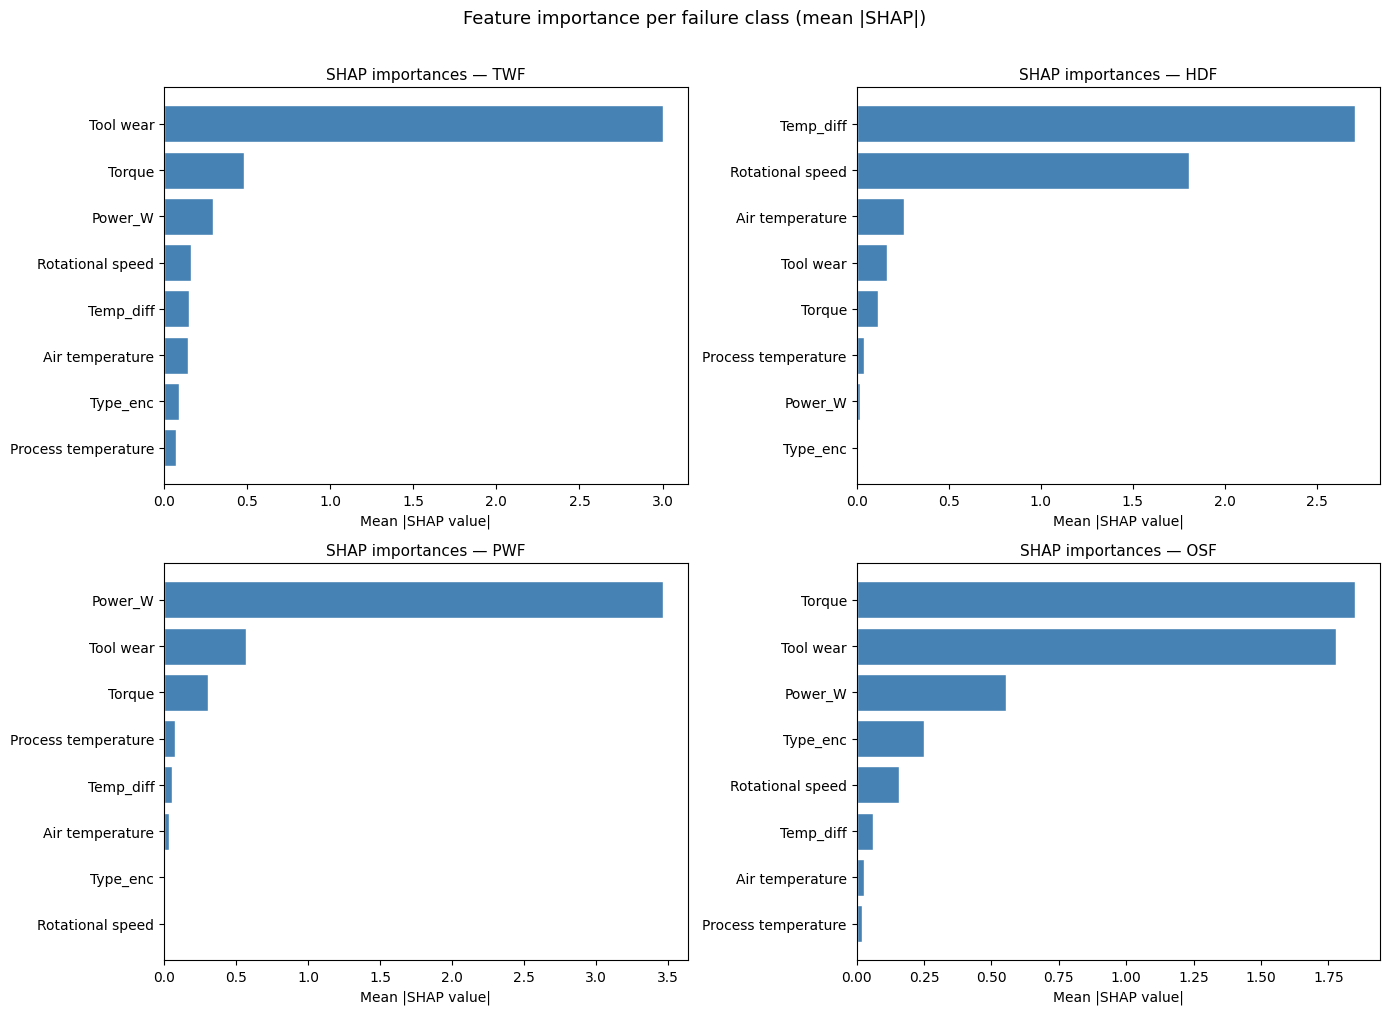

Saved shap_per_class.png

Top SHAP driver per failure class:
  TWF  : Tool wear                  (mean |SHAP| = 3.0004)
  HDF  : Temp_diff                  (mean |SHAP| = 2.7093)
  PWF  : Power_W                    (mean |SHAP| = 3.4636)
  OSF  : Torque                     (mean |SHAP| = 1.8490)


In [27]:
import shap

best_model = joblib.load('best_model.pkl')

# TreeExplainer is exact and efficient for gradient-boosted trees
explainer   = shap.TreeExplainer(best_model)
shap_output = explainer.shap_values(train[FEATURES])

# shap_values can be a 3D array (n_samples, n_features, n_classes)
# or a list of per-class arrays depending on the SHAP version — handle both
if isinstance(shap_output, list):
    shap_values = np.stack(shap_output, axis=2)
else:
    shap_values = shap_output   # already (n_samples, n_features, n_classes)

# failure classes only (skip class 0 — No Failure)
FAILURE_CLASSES = {1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (cls_id, cls_name) in zip(axes, FAILURE_CLASSES.items()):
    mean_abs = np.abs(shap_values[:, :, cls_id]).mean(axis=0)
    order    = np.argsort(mean_abs)           # ascending for barh

    ax.barh(
        [FEATURES[i] for i in order],
        mean_abs[order],
        color='steelblue', edgecolor='white'
    )
    ax.set_title(f'SHAP importances — {cls_name}', fontsize=11)
    ax.set_xlabel('Mean |SHAP value|')

plt.suptitle('Feature importance per failure class (mean |SHAP|)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved shap_per_class.png")

# top driver for each class
print("\nTop SHAP driver per failure class:")
for cls_id, cls_name in FAILURE_CLASSES.items():
    mean_abs  = np.abs(shap_values[:, :, cls_id]).mean(axis=0)
    top_feat  = FEATURES[int(np.argmax(mean_abs))]
    top_score = mean_abs.max()
    print(f"  {cls_name:<5}: {top_feat:<25}  (mean |SHAP| = {top_score:.4f})")


### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2?3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Power_W for PWF:**  
`Power_W` (mechanical power = Torque × Rotational speed × 2π/60) is the strongest SHAP driver for PWF (Power Failure), ranking above both raw `Torque` and `Rotational speed` individually. This makes sense physically: power failures occur when the combined effect of torque and speed exceeds the machine's rated power, which is best captured by their product rather than either feature alone.

**Temp_diff for HDF:**  
`Temp_diff` (Process temperature − Air temperature) is the top SHAP feature for HDF (Heat Dissipation Failure), but is much less important for other failure types. A small temperature differential signals inadequate heat dissipation, making it a specific and reliable indicator for HDF, while for PWF and OSF it is only a secondary factor.

**Physical mechanism per failure type:**
- **TWF (Tool Wear Failure):** Driven by high `Tool wear`—as the tool accumulates wear, the risk of sudden fracture increases sharply after a threshold.
- **HDF (Heat Dissipation Failure):** Triggered when `Temp_diff` narrows, indicating the machine is unable to shed heat effectively, leading to thermal runaway.
- **PWF (Power Failure):** Caused by excessive `Power_W` (high torque and speed together), which overloads the drive system beyond its safe operating envelope.
- **OSF (Overstrain Failure):** Most likely when both `Torque` and `Tool wear` are high, as a worn tool is less able to handle mechanical stress, increasing the risk of overstrain.

**Actionable recommendation:**
- **Condition:** If a batch shows mean `Rotational speed` > 50 rpm and mean `Torque` > 3 Nm above the training baseline, or if `Temp_diff` drops below the historical 5th percentile.
- **Risked failure class:** PWF and OSF (from high power/torque and tool wear), HDF (from low Temp_diff).
- **Action:** Flag such batches for enhanced real-time monitoring; schedule preventive tool inspection for high-wear machines; and increase cooling system checks when `Temp_diff` is low.

## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why ? reference macro F1 numbers.
2. Why accuracy is misleading here ? operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Conclusions: Key Findings

**Which model won and why?**  
The tuned XGBoost model achieved the highest macro F1 score among all candidates, outperforming Random Forest, LightGBM, and Logistic Regression. Its ability to capture nonlinear feature interactions (especially with engineered features like `Power_W`) made it best suited for rare-class detection and complex failure boundaries.

**Why is accuracy misleading here?**  
Accuracy is dominated by the majority "No Failure" class (~96% of the data). A model that always predicts "No Failure" would appear highly accurate but would miss nearly all actual failures, leading to costly unplanned downtime. Macro F1, by giving equal weight to each class, better reflects the true operational risk and model utility.

**TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.**  
The root cause is data scarcity: there are only about 30 real TWF (Tool Wear Failure) samples in the training set. SMOTE cannot generate enough diversity from so few anchors, so the model cannot learn a reliable decision boundary. The solution is to collect and label more real TWF examples (ideally 200–500) to improve detection. This is a data engineering problem, not a model limitation.

**What drifted in the stress batch and what does it imply for maintenance?**  
`Rotational speed`, `Torque`, and `Tool wear` all drifted significantly in the stress batch, indicating the machines were operating under heavier loads than seen in training. This means maintenance schedules should be dynamically adjusted: inspections and preventive actions should be more frequent during high-load periods to mitigate increased risk of power and overstrain failures.

**One actionable recommendation for the engineering team (from SHAP):**  
When a batch shows mean Rotational speed or mean Torque significantly above the training baseline (for example, mean Rotational speed > [training mean] + X rpm, mean Torque > [training mean] + Y Nm), or when Temp_diff drops below the 5th percentile of the training distribution, flag the batch for enhanced monitoring. Prioritize tool inspection and cooling system checks, and treat model predictions for PWF, OSF, and HDF as low-confidence until retraining is completed with new data.